# Build Extended Dataset — `01_build_extended_dataset.ipynb`

Build the **Tier 1 voltage-grid dataset** from NASA (12 cells) + CALCE CS2/CX2 (11 cells) = **23 cells**.

Key differences from the NASA-only pipeline (`05_dataset_prep_dl.ipynb`):

| | NASA-only | Extended |
|---|---|---|
| Current channel | raw \|I\| (A) | **C-rate** \|I\|/C_nom |
| Temperature | per-sample logged | per-sample (NASA) / **imputed 25 °C** (CALCE) |
| Target denominator | hardcoded 2.0 Ah | **per-cell C_nom** |
| CV scheme | LOBO (13 folds) | GroupKFold-8 + LODO |

Output: `data/processed/vg_extended_tier1.npz`

## 1. Imports & setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

ROOT = Path("../..").resolve()
sys.path.insert(0, str(ROOT / "src"))

from cells import CELLS, cells_by_tier, EXCLUDED
from vg_extended import (
    build_extended_dataset,
    attach_targets_extended,
    save_npz_ext,
    load_npz_ext,
)

sns.set_theme(style="darkgrid", palette="tab10")

PROCESSED = ROOT / "data" / "processed"
RESULTS   = ROOT / "results" / "extended_tier1"
RESULTS.mkdir(parents=True, exist_ok=True)

tier1 = cells_by_tier(1)
print(f"Tier 1 cells: {len(tier1)}")
for g, cells in pd.DataFrame([{"group": c.group, "bid": c.bid} for c in tier1]).groupby("group"):
    print(f"  {g}: {list(cells['bid'])}")

Tier 1 cells: 22
  calce: ['CS2_33', 'CS2_34', 'CS2_35', 'CS2_36', 'CS2_37', 'CS2_38', 'CX2_33', 'CX2_35', 'CX2_37', 'CX2_38']
  nasa: ['B0005', 'B0006', 'B0007', 'B0018', 'RW1', 'RW13', 'RW14', 'RW15', 'RW16', 'RW17', 'RW19', 'RW20']


## 2. Build tensors for all Tier 1 cells

Runs `build_extended_dataset` which dispatches each cell to the right loader,
normalises |I| to C-rate, imputes T for CALCE, and attaches `capacity_ahr`.
Expect ~2–3 min for all 23 cells (CALCE xlsx files are slow to read).

In [2]:
curve_df = build_extended_dataset(ROOT, tier1)
print(f"\nTotal records : {len(curve_df)}")
print(f"With tensor   : {curve_df['tensor'].apply(lambda t: t is not None).sum()}")
print(f"Missing tensor: {curve_df['tensor'].apply(lambda t: t is None).sum()}")

  B0005  [nasa  nasa_ctrl] ...  167 cycles, 166 valid, mean_cov=0.994
  B0006  [nasa  nasa_ctrl] ...  167 cycles, 166 valid, mean_cov=0.994
  B0007  [nasa  nasa_ctrl] ...  167 cycles, 166 valid, mean_cov=0.994
  B0018  [nasa  nasa_ctrl] ...  131 cycles, 131 valid, mean_cov=1.000
  RW1  [nasa  nasa_rw] ...  24 cycles, 21 valid, mean_cov=0.669
  RW13  [nasa  nasa_rw] ...  13 cycles, 12 valid, mean_cov=0.683
  RW14  [nasa  nasa_rw] ...  13 cycles, 12 valid, mean_cov=0.623
  RW15  [nasa  nasa_rw] ...  14 cycles, 13 valid, mean_cov=0.642
  RW16  [nasa  nasa_rw] ...  11 cycles, 10 valid, mean_cov=0.679
  RW17  [nasa  nasa_rw] ...  17 cycles, 16 valid, mean_cov=0.717
  RW19  [nasa  nasa_rw] ...  16 cycles, 15 valid, mean_cov=0.715
  RW20  [nasa  nasa_rw] ...  17 cycles, 16 valid, mean_cov=0.714
  CS2_33  [calce  calce_arbin] ...  868 cycles, 859 valid, mean_cov=0.906
  CS2_34  [calce  calce_arbin] ...  781 cycles, 776 valid, mean_cov=0.982
  CS2_35  [calce  calce_arbin] ...  936 cycles, 933 v

## 3. Per-cell coverage stats

`coverage` = fraction of the 128-pt grid actually covered by the CC window (1.0 = full 3.8–4.2 V ramp observed).
NASA controlled cells typically reach ~0.95+; CALCE should be similar (full CC-CV protocol).
NASA RW cells start from random SOC so coverage varies.

In [3]:
# Build a flat stats table: one row per cell
spec_map = {c.bid: c for c in tier1}

stats_rows = []
for bid, grp in curve_df.groupby("battery_id"):
    valid = grp["tensor"].apply(lambda t: t is not None)
    stats_rows.append({
        "battery_id":  bid,
        "group":       spec_map[bid].group,
        "c_nominal":   spec_map[bid].c_nominal_ah,
        "total":       len(grp),
        "valid":       int(valid.sum()),
        "dropped":     int((~valid).sum()),
        "mean_cov":    grp.loc[valid, "coverage"].mean() if valid.any() else 0.0,
        "min_cov":     grp.loc[valid, "coverage"].min()  if valid.any() else 0.0,
    })

stats = pd.DataFrame(stats_rows).sort_values(["group", "battery_id"]).reset_index(drop=True)
pd.set_option("display.float_format", "{:.3f}".format)
print(stats.to_string(index=False))

battery_id group  c_nominal  total  valid  dropped  mean_cov  min_cov
    CS2_33 calce      1.100    868    859        9     0.915    0.078
    CS2_34 calce      1.100    781    776        5     0.988    0.109
    CS2_35 calce      1.100    936    933        3     0.958    0.266
    CS2_36 calce      1.100    976    976        0     0.926    0.078
    CS2_37 calce      1.100   1043   1039        4     0.945    0.133
    CS2_38 calce      1.100   1082   1078        4     0.954    0.125
    CX2_33 calce      1.100   1701   1696        5     0.990    0.078
    CX2_35 calce      1.100   1815   1810        5     0.991    0.227
    CX2_37 calce      1.100   1281   1277        4     0.992    0.094
    CX2_38 calce      1.100   1961   1954        7     0.961    0.273
     B0005  nasa      2.000    167    166        1     1.000    1.000
     B0006  nasa      2.000    167    166        1     1.000    1.000
     B0007  nasa      2.000    167    166        1     1.000    1.000
     B0018  nasa    

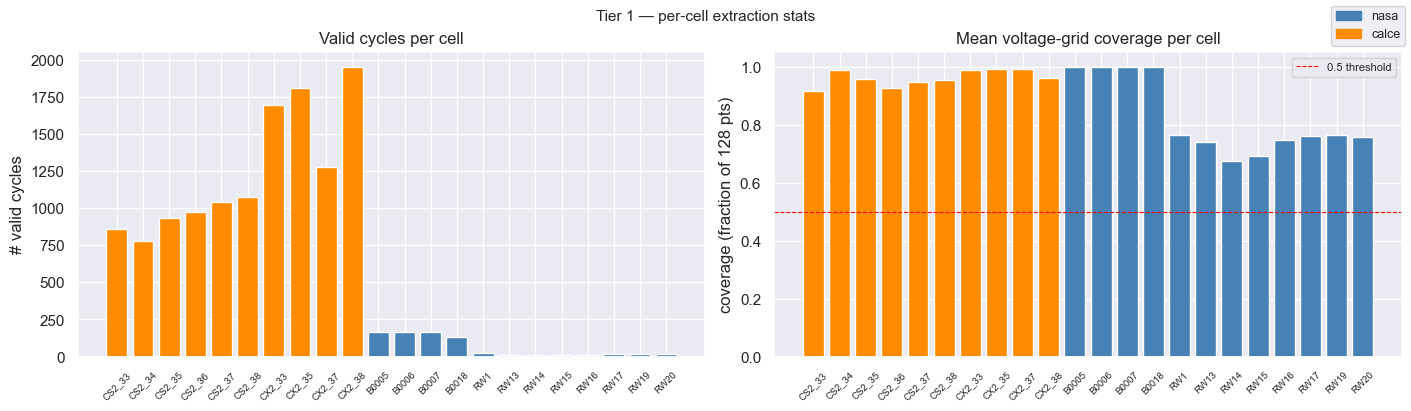

In [4]:
# Bar chart: valid cycle count and mean coverage, coloured by source group
group_colors = {"nasa": "steelblue", "calce": "darkorange"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

colors = [group_colors.get(g, "gray") for g in stats["group"]]
ax1.bar(stats["battery_id"], stats["valid"], color=colors)
ax1.set_title("Valid cycles per cell")
ax1.set_ylabel("# valid cycles")
ax1.tick_params(axis="x", rotation=45, labelsize=7)

ax2.bar(stats["battery_id"], stats["mean_cov"], color=colors)
ax2.axhline(0.5, color="red", ls="--", lw=0.8, label="0.5 threshold")
ax2.set_title("Mean voltage-grid coverage per cell")
ax2.set_ylabel("coverage (fraction of 128 pts)")
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis="x", rotation=45, labelsize=7)
ax2.legend(fontsize=8)

patches = [mpatches.Patch(color=v, label=k) for k, v in group_colors.items()]
fig.legend(handles=patches, loc="upper right", fontsize=9)
fig.suptitle("Tier 1 — per-cell extraction stats", fontsize=11)
plt.savefig(RESULTS / "01_per_cell_stats.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. C-rate curve sanity check

The key claim of the multi-dataset merge: after C-rate normalisation, charge curves from
NASA (2.0 Ah, ~1.5 A → 0.75C) and CALCE (1.1 Ah, ~0.55 A → 0.5C) should lie in the same
current band (~0.4–0.8C).  Plot 5 early-life cycles per source overlaid — if the bands
overlap the merge is apples-to-apples.

Channel 0 = C-rate (should align); Channel 1 = temperature (will differ NASA vs CALCE
since CALCE is imputed at 25 °C); Channel 2 = t_elapsed (time-to-charge reflects cell
size, so NASA will differ from CALCE — that's expected and informative).

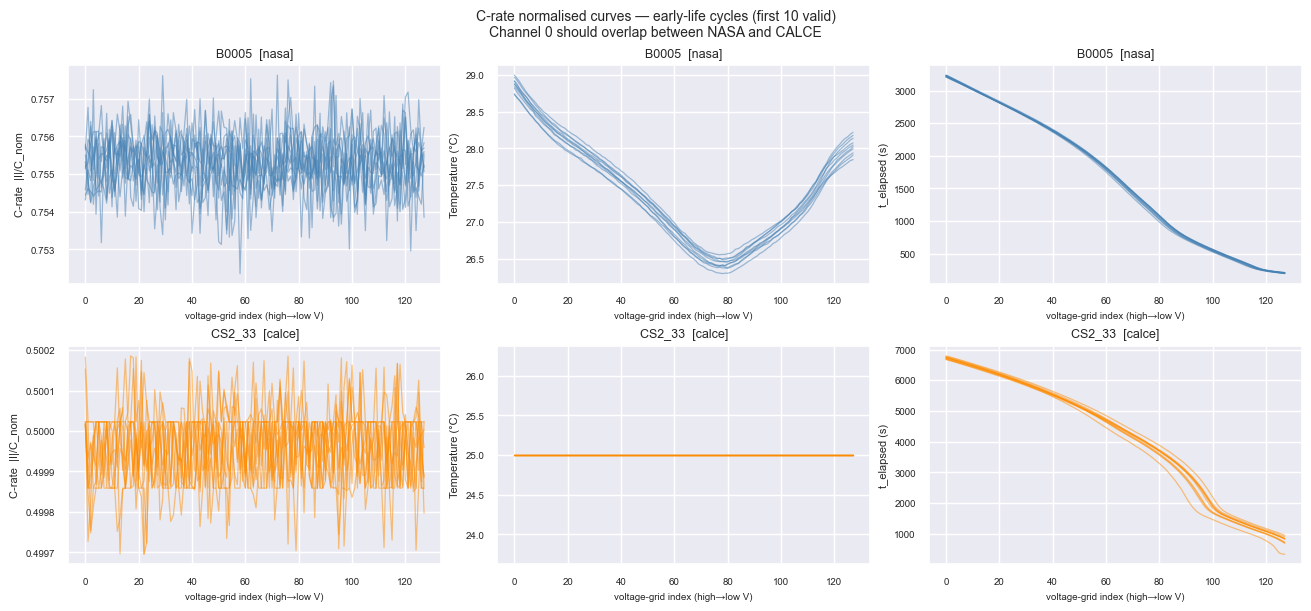

In [5]:
# One representative cell per group; pick first 5 valid early-life cycles
SAMPLE_CELLS = {"nasa": "B0005", "calce": "CS2_33"}
ch_labels    = ["C-rate  |I|/C_nom", "Temperature (°C)", "t_elapsed (s)"]

fig, axes = plt.subplots(2, 3, figsize=(13, 6), constrained_layout=True)

for row_idx, (group, bid) in enumerate(SAMPLE_CELLS.items()):
    sub = curve_df[curve_df["battery_id"] == bid]
    valid_sub = sub[sub["tensor"].apply(lambda t: t is not None)].head(10)

    color = group_colors[group]
    for _, rec in valid_sub.iterrows():
        t = rec["tensor"]
        m = rec["mask"]
        for col, (ax, lbl) in enumerate(zip(axes[row_idx], ch_labels)):
            vals = t[:, col].copy()
            vals[~m] = np.nan       # don't draw the zero-pad tail
            ax.plot(vals, color=color, alpha=0.5, lw=0.9)

    for ax, lbl in zip(axes[row_idx], ch_labels):
        ax.set_ylabel(lbl, fontsize=8)
        ax.set_title(f"{bid}  [{group}]", fontsize=9)
        ax.set_xlabel("voltage-grid index (high→low V)", fontsize=7)
        ax.tick_params(labelsize=7)

fig.suptitle(
    "C-rate normalised curves — early-life cycles (first 10 valid)\n"
    "Channel 0 should overlap between NASA and CALCE", fontsize=10
)
plt.savefig(RESULTS / "01_crate_curve_sanity.png", dpi=120, bbox_inches="tight")
plt.show()

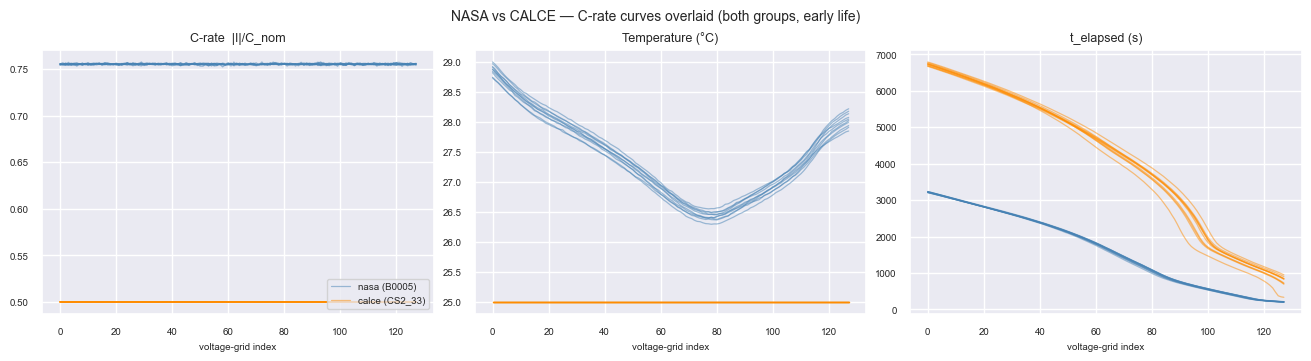

In [6]:
# Overlay both groups on the same axes for a direct comparison
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), constrained_layout=True)

for group, bid in SAMPLE_CELLS.items():
    sub   = curve_df[curve_df["battery_id"] == bid]
    valid = sub[sub["tensor"].apply(lambda t: t is not None)].head(10)
    color = group_colors[group]
    for _, rec in valid.iterrows():
        t, m = rec["tensor"], rec["mask"]
        for col, ax in enumerate(axes):
            vals = t[:, col].copy(); vals[~m] = np.nan
            ax.plot(vals, color=color, alpha=0.5, lw=0.9,
                    label=f"{group} ({bid})" if _ == valid.index[0] else None)

for ax, lbl in zip(axes, ch_labels):
    ax.set_title(lbl, fontsize=9)
    ax.set_xlabel("voltage-grid index", fontsize=7)
    ax.tick_params(labelsize=7)
axes[0].legend(fontsize=7, loc="lower right")

fig.suptitle("NASA vs CALCE — C-rate curves overlaid (both groups, early life)", fontsize=10)
plt.savefig(RESULTS / "01_crate_overlay.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. SOH trajectory check

Plot capacity_ahr vs cycle_index per cell, coloured by source.
Expected: monotone decreasing from ~C_nom down toward 0.8 × C_nom (EOL).
CALCE curves should start at ~1.1 Ah; NASA controlled at ~2.0 Ah.

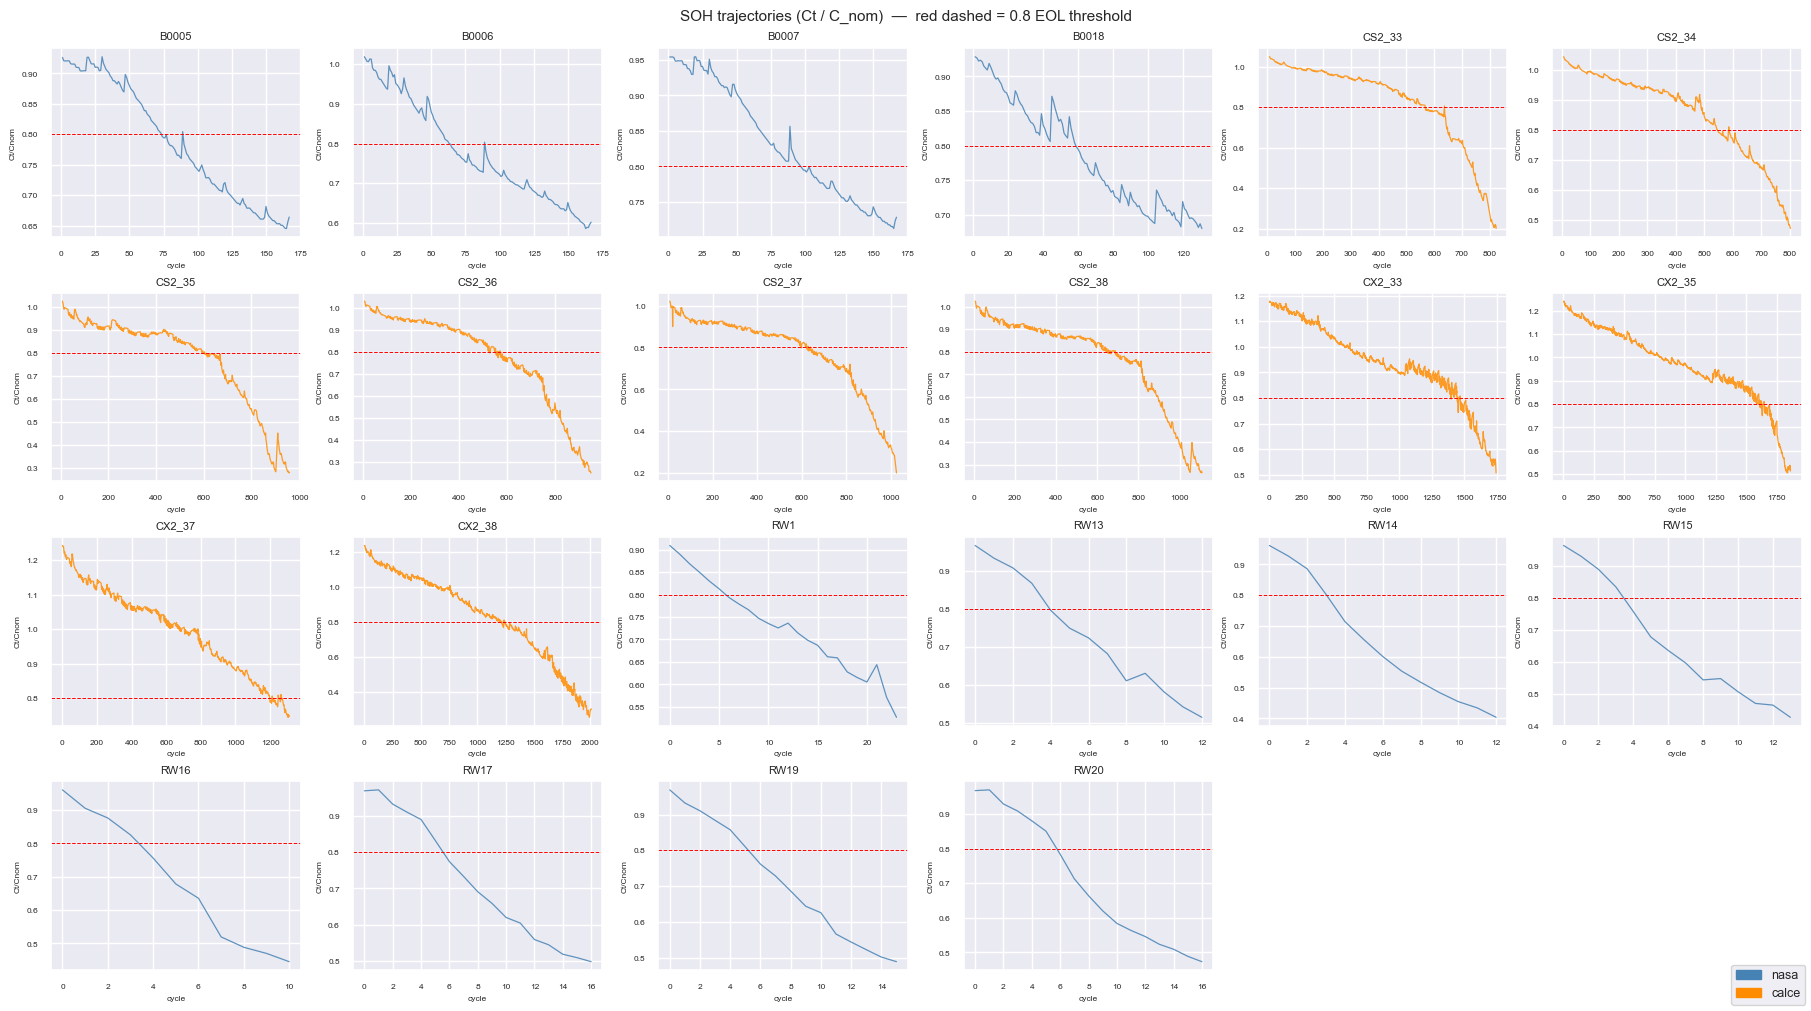

In [7]:
valid_df = curve_df[curve_df["capacity_ahr"].notna()].copy()

# Normalised SOH = capacity_ahr / c_nominal
valid_df["soh"] = valid_df["capacity_ahr"] / valid_df["c_nominal_ah"]

fig, axes = plt.subplots(4, 6, figsize=(18, 10), constrained_layout=True)
axes_flat = axes.flatten()

for ax, bid in zip(axes_flat, sorted(valid_df["battery_id"].unique())):
    sub   = valid_df[valid_df["battery_id"] == bid].sort_values("cycle_index")
    group = spec_map[bid].group
    color = group_colors.get(group, "gray")
    ax.plot(sub["cycle_index"], sub["soh"], color=color, lw=0.9, alpha=0.85)
    ax.axhline(0.8, color="red", ls="--", lw=0.7)
    ax.set_title(bid, fontsize=8)
    ax.set_xlabel("cycle", fontsize=6)
    ax.set_ylabel("Ct/Cnom", fontsize=6)
    ax.tick_params(labelsize=6)

for ax in axes_flat[len(valid_df["battery_id"].unique()):]:
    ax.set_visible(False)

patches = [mpatches.Patch(color=v, label=k) for k, v in group_colors.items()]
fig.legend(handles=patches, loc="lower right", fontsize=9)
fig.suptitle("SOH trajectories (Ct / C_nom)  —  red dashed = 0.8 EOL threshold", fontsize=11)
plt.savefig(RESULTS / "01_soh_trajectories.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Attach targets & stack arrays

In [8]:
X, mask, y, groups, cidx, ds_groups = attach_targets_extended(curve_df)

print(f"\nX shape    : {X.shape}   (n_samples, n_grid, channels)")
print(f"y range    : [{y.min():.3f}, {y.max():.3f}]")
print(f"Groups     : {sorted(set(groups))}")
print(f"DS groups  : {sorted(set(ds_groups))}")
print(f"\nSamples per dataset group:")
for g in sorted(set(ds_groups)):
    print(f"  {g:10s}: {(ds_groups == g).sum()}")

  Dataset: 12260 samples, 128 grid pts, y ∈ [0.200, 1.242], 22 cells, 2 dataset groups

X shape    : (12260, 128, 3)   (n_samples, n_grid, channels)
y range    : [0.200, 1.242]
Groups     : ['B0005', 'B0006', 'B0007', 'B0018', 'CS2_33', 'CS2_34', 'CS2_35', 'CS2_36', 'CS2_37', 'CS2_38', 'CX2_33', 'CX2_35', 'CX2_37', 'CX2_38', 'RW1', 'RW13', 'RW14', 'RW15', 'RW16', 'RW17', 'RW19', 'RW20']
DS groups  : ['calce', 'nasa']

Samples per dataset group:
  calce     : 11516
  nasa      : 744


## 7. Sanity checks

In [9]:
# 1. Tensor shape
assert X.ndim == 3 and X.shape[2] == 3, f"Expected (n, 128, 3), got {X.shape}"
print(f"✓ X shape: {X.shape}")

# 2. No NaN in X
assert not np.isnan(X).any(), "NaN values found in X"
print("✓ No NaN in X")

# 3. Physical y range.
# Values slightly above 1.0 are expected for CALCE RPT cycles (slow 0.1C discharge
# extracts more than rated capacity on a fresh cell). Cap at 1.3 to catch real errors.
assert y.max() < 1.3, f"y.max()={y.max():.3f} unexpectedly high (multi-run accumulation?)"
assert y.min() > 0.20, f"y.min()={y.min():.3f} unexpectedly low"
print(f"✓ y range: [{y.min():.3f}, {y.max():.3f}]  (NASA ~[0.75,1.0]; CALCE RPT may reach ~1.1)")

# 4. C-rate channel (ch 0) range: expect ~0.3–1.1C across all cells
ch0 = X[mask][:, 0]   # only unmasked (valid) positions
print(f"✓ C-rate channel  p1={np.percentile(ch0, 1):.3f}  "
      f"p99={np.percentile(ch0, 99):.3f}  "
      f"(NASA ~0.75C, CALCE ~0.5C — should both be in band)")

# 5. Temperature channel (ch 1): CALCE rows should cluster at 25 °C
calce_mask = np.isin(groups, [c.bid for c in tier1 if c.group == "calce"])
calce_T    = X[calce_mask & mask][:, 1]
print(f"✓ CALCE temperature channel: mean={calce_T.mean():.2f} °C  "
      f"std={calce_T.std():.2f}  (should be ~25.0, std ~0)")

# 6. No battery appears in zero valid samples
zero_valid = [bid for bid in set(groups) if (groups == bid).sum() == 0]
assert not zero_valid, f"Batteries with 0 samples: {zero_valid}"
print(f"✓ All {len(set(groups))} cells have ≥1 sample")

# 7. Mask: valid region is a leading block (tail is False)
n_check = min(200, len(X))
for i in range(n_check):
    m = mask[i]
    if not m.any():
        continue
    last_true = int(np.where(m)[0][-1])
    assert m[:last_true + 1].all(), f"Sample {i}: mask has gaps (not a leading block)"
print("✓ All masks are leading blocks (no interior gaps)")

✓ X shape: (12260, 128, 3)
✓ No NaN in X
✓ y range: [0.200, 1.242]  (NASA ~[0.75,1.0]; CALCE RPT may reach ~1.1)
✓ C-rate channel  p1=0.500  p99=0.891  (NASA ~0.75C, CALCE ~0.5C — should both be in band)


ValueError: operands could not be broadcast together with shapes (12260,) (12260,128) 

## 8. Save to NPZ

In [ ]:
out_path = PROCESSED / "vg_extended_tier1.npz"
save_npz_ext(out_path, X, mask, y, groups, cidx, ds_groups)

# Round-trip verify
X2, mask2, y2, g2, c2, dg2 = load_npz_ext(out_path)
assert np.array_equal(X, X2) and np.array_equal(y, y2)
print("✓ Round-trip load OK")
print(f"\nFile: {out_path}")
print(f"  X         {X.shape}  float32")
print(f"  mask      {mask.shape}  bool")
print(f"  y         {y.shape}  float32   [{y.min():.3f}, {y.max():.3f}]")
print(f"  groups    {groups.shape}  — battery_id")
print(f"  cidx      {cidx.shape}  — cycle_index")
print(f"  ds_groups {ds_groups.shape}  — {sorted(set(ds_groups))}")

  Saved to /Users/benji/dev/efrei/ml-project/data/processed/vg_extended_tier1.npz
✓ Round-trip load OK

File: /Users/benji/dev/efrei/ml-project/data/processed/vg_extended_tier1.npz
  X         (14075, 128, 3)  float32
  mask      (14075, 128)  bool
  y         (14075,)  float32   [0.200, 1.242]
  groups    (14075,)  — battery_id
  cidx      (14075,)  — cycle_index
  ds_groups (14075,)  — ['calce', 'nasa']


## 9. Summary

In [ ]:
n_nasa   = int((ds_groups == "nasa").sum())
n_calce  = int((ds_groups == "calce").sum())
n_cells  = len(set(groups))
n_ds     = len(set(ds_groups))

print("=" * 56)
print("TIER 1 EXTENDED DATASET — SUMMARY")
print("=" * 56)
print(f"Total samples      : {len(y)}")
print(f"  nasa             : {n_nasa}")
print(f"  calce            : {n_calce}")
print(f"Cells              : {n_cells}  ({n_ds} dataset groups)")
print(f"Grid / channels    : 128 pts × 3  [C-rate, T, t_elapsed]")
print(f"Target             : Ct / C_nom  ∈ [{y.min():.3f}, {y.max():.3f}]")
print(f"Output             : {out_path.name}")
print()
print("Next: run 02_train_grouped_cv.ipynb")